# 02 — Modélisation supervisée : CNN scratch, DenseNet, EfficientNet, ViT

Ce notebook implémente et compare 3 architectures en Keras/TensorFlow :
1. **CNN from scratch** — architecture convolutive légère, 1 canal
2. **DenseNet-121** — transfer learning depuis ImageNet (keras.applications)
3. **EfficientNetV2-S** — transfer learning alternatif + ViT via keras_cv

Tracking MLflow complet. Métrique principale : ROC-AUC macro.

In [1]:
import json
import random
import time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import DenseNet121, EfficientNetV2S
from keras.applications.densenet import preprocess_input as densenet_preprocess
from keras.applications.efficientnet_v2 import preprocess_input as effnet_preprocess

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report

import mlflow
import mlflow.keras
DATA_DIR   = Path('../Projet_Deep_Learning/data/variable_data')
MODELS_DIR = Path('../Projet_Deep_Learning/models')
MODELS_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / 'config.json') as f:
    cfg = json.load(f)

SEED        = cfg['seed']
IMG_SIZE    = cfg['img_size']
BATCH_SIZE  = 512
N_CLASSES   = cfg['n_classes']
CLASS_NAMES = cfg['class_names']
POS_WEIGHT  = np.array(cfg['pos_weight'], dtype=np.float32)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

2026-03-28 11:28:48.133363: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 11:28:52.925286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-03-28 11:29:08.697278: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0 | Keras 3.12.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Chargement des données

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import gc

# on limite la consommation VRAM de la 3070 pour eviter les OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("La GPU allouera la mémoire dynamiquement.")
    except RuntimeError as e:
        print(f"Erreur config GPU : {e}")

# avec mmap_mode='r' les fichiers restent sur disque et on ne charge que ce qu'on lit, ca evite de saturer la RAM
print("Ouverture des fichiers via Memory Mapping (lecture directe du disque)...")
try:
    X_train_raw = np.load(DATA_DIR / 'X_train_rgb.npy', mmap_mode='r')
    X_val_raw   = np.load(DATA_DIR / 'X_val_rgb.npy', mmap_mode='r')
    X_test_raw  = np.load(DATA_DIR / 'X_test_rgb.npy', mmap_mode='r')

    y_train = np.load(DATA_DIR / 'y_train.npy')
    y_val   = np.load(DATA_DIR / 'y_val.npy')
    y_test  = np.load(DATA_DIR / 'y_test.npy')
    print(f"Fichiers liés. Train: {X_train_raw.shape[0]} images.")
except FileNotFoundError:
    print("Vérifie tes chemins, fichiers .npy manquants.")

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
], name='augmentation')

# on passe par un generateur pour que TensorFlow ne charge que les batchs dont il a besoin
def build_dataset(X, y, shuffle=False, augment=False, batch_size=None):
    def generator():
        for i in range(len(X)):
            # la conversion en float32 se fait ici, image par image, pour ne pas exploser la RAM
            yield X[i].astype(np.float32), y[i].astype(np.float32)

    # on construit le dataset a partir du generateur
    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=X.shape[1:], dtype=tf.float32),
            tf.TensorSpec(shape=y.shape[1:], dtype=tf.float32)
        )
    )

    if shuffle:
        # buffer reduit pour ne pas surcharger la RAM pendant le shuffle
        ds = ds.shuffle(buffer_size=1000, seed=SEED)

    bs = batch_size if batch_size is not None else BATCH_SIZE
    ds = ds.batch(bs)

    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)

print("Préparation des datasets par batchs...")
train_ds_rgb = build_dataset(X_train_raw, y_train, shuffle=True, augment=True)
val_ds_rgb   = build_dataset(X_val_raw,   y_val)
test_ds_rgb  = build_dataset(X_test_raw,  y_test)

# pas de 'del' ici parce que le generateur a besoin que les objets X_raw restent ouverts
print("Datasets prêts. La RAM est préservée grâce au Memory Mapping.")
# on charge aussi les images en niveaux de gris pour le CNN scratch (1 canal, normalise entre -1 et 1)
X_train_gray = np.load(DATA_DIR / 'X_train_norm.npy', mmap_mode='r')
X_val_gray   = np.load(DATA_DIR / 'X_val_norm.npy',   mmap_mode='r')
X_test_gray  = np.load(DATA_DIR / 'X_test_norm.npy',  mmap_mode='r')

train_ds_gray = build_dataset(X_train_gray, y_train, shuffle=True, augment=True)
val_ds_gray   = build_dataset(X_val_gray,   y_val)
test_ds_gray  = build_dataset(X_test_gray,  y_test)

print(f'Gray datasets prets: {X_train_gray.shape}')

# batch reduit pour l'evaluation finale, le mode eager garde toutes les activations en memoire
EVAL_BATCH = 64
test_ds_gray = build_dataset(X_test_gray, y_test, batch_size=EVAL_BATCH)
test_ds_rgb  = build_dataset(X_test_raw,  y_test, batch_size=EVAL_BATCH)

La GPU allouera la mémoire dynamiquement.
Ouverture des fichiers via Memory Mapping (lecture directe du disque)...
Fichiers liés. Train: 78468 images.


I0000 00:00:1774693768.793497   38820 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Préparation des datasets par batchs...


Datasets prêts. La RAM est préservée grâce au Memory Mapping.
Gray datasets prets: (78468, 64, 64, 1)


## 2. Fonction de perte pondérée multi-label

In [3]:
class WeightedBCE(keras.losses.Loss):
    """Binary cross-entropy avec poids positifs par classe pour compenser le déséquilibre.
    
    Équivalent à BCEWithLogitsLoss(pos_weight=...) de PyTorch.
    Les logits sont attendus — le sigmoid est calculé en interne.
    """
    def __init__(self, pos_weight: np.ndarray, **kwargs):
        super().__init__(**kwargs)
        self.pos_weight = tf.constant(pos_weight, dtype=tf.float32)

    def call(self, y_true, y_pred_logits):
        # formulation numeriquement stable qui evite les overflow, equivalente a la version avec max(x,0)
        bce = tf.nn.weighted_cross_entropy_with_logits(
            labels=tf.cast(y_true, tf.float32),
            logits=y_pred_logits,
            pos_weight=self.pos_weight
        )
        return tf.reduce_mean(bce)

    def get_config(self):
        cfg = super().get_config()
        cfg['pos_weight'] = self.pos_weight.numpy().tolist()
        return cfg


weighted_bce = WeightedBCE(POS_WEIGHT)
print('WeightedBCE définie')

WeightedBCE définie


## 3. Architecture 1 — CNN entraîné depuis zéro

In [4]:
def build_cnn_scratch(img_size: int, n_classes: int, dropout_rate: float = 0.4) -> Model:
    """CNN convolutif léger à 4 blocs conv+BN+ReLU.
    
    Architecture suffisamment profonde pour capturer les structures thoraciques
    sans sur-paramétrage. AdaptiveAveragePooling via GlobalAveragePooling2D.
    """
    inp = layers.Input(shape=(img_size, img_size, 1), name='input_gray')

    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)

    # on elargit a 256 filtres ici pour capter des features plus complexes
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    # pas d'activation finale, la WeightedBCE s'attend a recevoir des logits bruts
    out = layers.Dense(n_classes, name='logits')(x)

    return Model(inp, out, name='CNN_scratch')


model_scratch = build_cnn_scratch(IMG_SIZE, N_CLASSES)
model_scratch.summary(line_length=80)
print(f'Paramètres entraînables: {model_scratch.count_params():,}')

Model: "CNN_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_gray (InputLayer)           │ (None, 64, 64, 1)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 64, 64, 32)       │           288 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 64, 64, 32)       │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation (Activation)           │ (None, 64, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 32, 32, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 32, 32, 64)       │        18,432 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 32, 32, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_1 (Activation)         │ (None, 32, 32, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 16, 16, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 16, 16, 128)      │        73,728 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 16, 16, 128)      │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_2 (Activation)         │ (None, 16, 16, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 8, 8, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 8, 8, 256)        │       294,912 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_3             │ (None, 8, 8, 256)        │         1,024 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_3 (Activation)         │ (None, 8, 8, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 256)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 512)              │       131,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ logits (Dense)                    │ (None, 14)               │         7,182 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 528,046 (2.01 MB)

 Trainable params: 527,086 (2.01 MB)

 Non-trainable params: 960 (3.75 KB)

Paramètres entraînables: 528,046


## 4. Architecture 2 — DenseNet-121 avec transfer learning

In [5]:
def build_densenet(img_size: int, n_classes: int, freeze_backbone: bool = False) -> Model:
    """DenseNet-121 pré-entraîné sur ImageNet, tête remplacée pour multi-label.
    
    DenseNet est historiquement pertinent pour l'imagerie thoracique (CheXNet).
    preprocess_input DenseNet attend des pixels dans [-1, 1] environ — on applique
    la normalisation ImageNet interne via un layer Lambda.
    """
    inp = layers.Input(shape=(img_size, img_size, 3), name='input_rgb')

    # on integre la normalisation ImageNet directement dans le graphe, comme ca le pretraitement est automatiquement applique en inference aussi
    x = layers.Lambda(
        lambda img: densenet_preprocess(img * 255.0),
        name='imagenet_preprocess'
    )(inp)

    backbone = DenseNet121(include_top=False, weights='imagenet',
                           input_shape=(img_size, img_size, 3),
                           pooling='avg')
    backbone.trainable = not freeze_backbone

    x   = backbone(x, training=not freeze_backbone)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, name='logits')(x)

    return Model(inp, out, name='DenseNet121_TL')


model_densenet = build_densenet(IMG_SIZE, N_CLASSES)
trainable = sum(1 for w in model_densenet.trainable_weights)
print(f'DenseNet-121 — poids entraînables: {model_densenet.count_params():,}')

DenseNet-121 — poids entraînables: 7,051,854


## 5. Architecture 3 — EfficientNetV2-S avec transfer learning

In [6]:
def build_efficientnet(img_size: int, n_classes: int) -> Model:
    """EfficientNetV2-S — alternative moderne à DenseNet.
    
    EfficientNetV2 offre un meilleur compromis paramètres/performance que DenseNet
    sur des datasets de taille modérée. L'architecture Fused-MBConv est plus
    efficace sur GPU.
    
    Note : pour les ressources limitées, EfficientNetV2-B0 peut être utilisé.
    """
    inp = layers.Input(shape=(img_size, img_size, 3), name='input_rgb')

    x = layers.Lambda(
        lambda img: effnet_preprocess(img * 255.0),
        name='imagenet_preprocess'
    )(inp)

    backbone = EfficientNetV2S(include_top=False, weights='imagenet',
                               input_shape=(img_size, img_size, 3),
                               pooling='avg')
    backbone.trainable = True

    x   = backbone(x, training=True)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, name='logits')(x)

    return Model(inp, out, name='EfficientNetV2S_TL')


model_effnet = build_efficientnet(IMG_SIZE, N_CLASSES)
print(f'EfficientNetV2-S — poids: {model_effnet.count_params():,}')

EfficientNetV2-S — poids: 20,349,294


## 6. Métriques personnalisées et utilitaires d'évaluation

In [7]:
def compute_multilabel_metrics(y_true: np.ndarray, y_scores: np.ndarray,
                                threshold: float = 0.5) -> dict:
    """ROC-AUC, PR-AUC et F1-macro pour classification multi-label."""
    y_true  = y_true.astype(int)
    y_pred  = (y_scores >= threshold).astype(int)
    valid   = [i for i in range(y_true.shape[1]) if y_true[:, i].sum() > 0]
    roc_auc = roc_auc_score(y_true[:, valid], y_scores[:, valid], average='macro')
    pr_auc  = average_precision_score(y_true[:, valid], y_scores[:, valid], average='macro')
    f1      = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'f1_macro': f1}


def predict_from_dataset(model: Model, dataset) -> tuple:
    """Collecte les prédictions sur un dataset tf.data complet."""
    all_scores, all_labels = [], []
    for X_batch, y_batch in dataset:
        logits  = model(X_batch, training=False)
        scores  = tf.sigmoid(logits).numpy()
        all_scores.append(scores)
        all_labels.append(y_batch.numpy())
    return np.vstack(all_scores), np.vstack(all_labels)


def plot_training_history(history: dict, model_name: str) -> str:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(history['loss']) + 1)

    axes[0].plot(epochs, history['loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for ax_idx, key in enumerate(['roc_auc_metric', 'f1_metric'], start=1):
        val_key = f'val_{key}'
        if key in history:
            axes[ax_idx].plot(epochs, history[key], label='Train')
        if val_key in history:
            axes[ax_idx].plot(epochs, history[val_key], label='Val')
        axes[ax_idx].set_title(key.replace('_metric', ''))
        axes[ax_idx].set_ylim(0, 1)
        axes[ax_idx].legend()
        axes[ax_idx].grid(alpha=0.3)

    plt.suptitle(f'Courbes d\'entraînement — {model_name}')
    plt.tight_layout()
    path = str(DATA_DIR / f'curves_{model_name}.png')
    plt.savefig(path, dpi=100)
    plt.close()
    return path


def plot_per_class_auc(y_true, y_scores, model_name: str) -> str:
    per_class = []
    for i, name in enumerate(CLASS_NAMES):
        auc = roc_auc_score(y_true[:, i], y_scores[:, i]) if y_true[:, i].sum() > 0 else float('nan')
        per_class.append({'class': name, 'auc': auc})
    df_auc = pd.DataFrame(per_class).sort_values('auc', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(df_auc['class'], df_auc['auc'], color='steelblue')
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_title(f'AUC par classe — {model_name} (test)')
    ax.invert_yaxis()
    plt.tight_layout()
    path = str(DATA_DIR / f'per_class_auc_{model_name}.png')
    plt.savefig(path, dpi=100)
    plt.close()
    return path

print('Utilitaires définis')

Utilitaires définis


## 7. Boucle d'entraînement Keras + MLflow

In [ ]:
def train_keras_model(model: Model, model_name: str,
                       train_ds, val_ds, test_ds,
                       n_epochs: int = 25, lr: float = 1e-3,
                       use_rgb: bool = False):
    """Compile, entraîne et évalue un modèle Keras avec tracking MLflow complet."""

    optimizer = keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4)

    model.compile(
        optimizer=optimizer,
        loss=weighted_bce,
        metrics=[
            keras.metrics.AUC(multi_label=True, num_labels=N_CLASSES, name='roc_auc_metric'),
            keras.metrics.AUC(multi_label=True, num_labels=N_CLASSES, curve='PR', name='pr_auc_metric'),
        ]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_roc_auc_metric', mode='max',
            patience=5, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_roc_auc_metric', mode='max',
            factor=0.5, patience=3, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(MODELS_DIR / f'{model_name}_best.keras'),
            monitor='val_roc_auc_metric', mode='max',
            save_best_only=True, verbose=0
        ),
    ]

    with mlflow.start_run(run_name=model_name):
        mlflow.log_params({
            'model':       model_name,
            'n_epochs':    n_epochs,
            'lr':          lr,
            'batch_size':  BATCH_SIZE,
            'img_size':    IMG_SIZE,
            'seed':        SEED,
            'optimizer':   'AdamW',
            'n_params':    model.count_params(),
            'input_mode':  'rgb' if use_rgb else 'gray',
        })

        t0      = time.time()
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=n_epochs,
            callbacks=callbacks,
            verbose=2
        )
        train_time = time.time() - t0

        for epoch_idx, loss_val in enumerate(history.history['loss']):
            mlflow.log_metrics({
                'train_loss':     loss_val,
                'val_loss':       history.history['val_loss'][epoch_idx],
                'val_roc_auc':    history.history['val_roc_auc_metric'][epoch_idx],
                'val_pr_auc':     history.history['val_pr_auc_metric'][epoch_idx],
            }, step=epoch_idx + 1)

        y_scores, y_true = predict_from_dataset(model, test_ds)
        test_metrics     = compute_multilabel_metrics(y_true, y_scores)

        print(f'\n[{model_name}] Test — AUC: {test_metrics["roc_auc"]:.4f} | '
              f'PR-AUC: {test_metrics["pr_auc"]:.4f} | F1: {test_metrics["f1_macro"]:.4f} | '
              f'Temps: {train_time:.0f}s')

        mlflow.log_metrics({
            'test_roc_auc':   test_metrics['roc_auc'],
            'test_pr_auc':    test_metrics['pr_auc'],
            'test_f1_macro':  test_metrics['f1_macro'],
            'train_time_sec': train_time,
        })

        curves_path   = plot_training_history(history.history, model_name)
        per_cls_path  = plot_per_class_auc(y_true, y_scores, model_name)
        mlflow.log_artifact(curves_path)
        mlflow.log_artifact(per_cls_path)
        mlflow.log_artifact(str(MODELS_DIR / f'{model_name}_best.keras'))
        mlflow.keras.log_model(model, artifact_path='model')

    return model, history.history, test_metrics, y_true, y_scores

print('Boucle d\'entraînement prête')

## 8. Entraînement — CNN scratch

In [9]:
mlflow.set_experiment('chest_classification_supervised')

model_scratch = build_cnn_scratch(IMG_SIZE, N_CLASSES)
scratch_model, scratch_hist, scratch_test, scratch_ytrue, scratch_yscores = train_keras_model(
    model_scratch, 'CNN_scratch',
    train_ds_gray, val_ds_gray, test_ds_gray,
    n_epochs=35, lr=1e-3, use_rgb=False
)

Epoch 1/35


2026-03-28 11:29:44.643963: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f11a40136b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-28 11:29:44.644000: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6


2026-03-28 11:29:45.143860: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-03-28 11:29:46.358129: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


2026-03-28 11:29:47.785717: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1838', 4 bytes spill stores, 4 bytes spill loads



...


[CNN_scratch] Test — AUC: 0.5000 | PR-AUC: 0.0527 | F1: 0.0626 | Temps: 363s


/tmp/ipykernel_38820/569971889.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[ax_idx].legend()


2026/03/28 11:36:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 11:36:02 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 11:37:26 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpnpu9fqs_/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


## 9. Entraînement — DenseNet-121

In [10]:
model_densenet = build_densenet(IMG_SIZE, N_CLASSES)
dense_model, dense_hist, dense_test, dense_ytrue, dense_yscores = train_keras_model(
    model_densenet, 'DenseNet121',
    train_ds_rgb, val_ds_rgb, test_ds_rgb,
    n_epochs=25, lr=5e-4, use_rgb=True
)

Epoch 1/25


      1/Unknown 151s 151s/step - loss: 2.0457 - pr_auc_metric: 0.0486 - roc_auc_metric: 0.4525

      2/Unknown 151s 237ms/step - loss: 1.9984 - pr_auc_metric: 0.0488 - roc_auc_metric: 0.4631

      3/Unknown 151s 235ms/step - loss: 1.9659 - pr_auc_metric: 0.0487 - roc_auc_metric: 0.4654

      4/Unknown 151s 235ms/step - loss: 1.9411 - pr_auc_metric: 0.0487 - roc_auc_metric: 0.4693

...


[DenseNet121] Test — AUC: 0.5066 | PR-AUC: 0.0552 | F1: 0.0715 | Temps: 645s


/tmp/ipykernel_38820/569971889.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[ax_idx].legend()


2026/03/28 11:50:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 11:50:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 11:51:20 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpemb0rj1n/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


## 10. Entraînement — EfficientNetV2-S

In [11]:
model_effnet = build_efficientnet(IMG_SIZE, N_CLASSES)
effnet_model, effnet_hist, effnet_test, effnet_ytrue, effnet_yscores = train_keras_model(
    model_effnet, 'EfficientNetV2S',
    train_ds_rgb, val_ds_rgb, test_ds_rgb,
    n_epochs=25, lr=3e-4, use_rgb=True
)

Epoch 1/25


2026-03-28 11:52:50.058409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-03-28 11:52:50.306417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-03-28 11:52:51.171462: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-03-28 11:52:51.430684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...


[EfficientNetV2S] Test — AUC: 0.7684 | PR-AUC: 0.1578 | F1: 0.1680 | Temps: 1118s


/tmp/ipykernel_38820/569971889.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[ax_idx].legend()


2026/03/28 12:12:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 12:12:43 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 12:13:35 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpxrf0h1ia/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


## 11. ViT via keras_hub (optionnel — requiert keras_hub)

In [12]:
# le ViT est implemente directement en Keras, pas besoin de librairie externe supplementaire

def mlp_block(x, hidden_dim: int, dropout_rate: float = 0.1):
    d_out = x.shape[-1]
    x = layers.Dense(hidden_dim, activation='gelu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(d_out)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def transformer_block(x, num_heads: int, key_dim: int, mlp_dim: int, dropout_rate: float = 0.1):
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                          dropout=dropout_rate)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    mlp_out = mlp_block(x, mlp_dim, dropout_rate)
    x = layers.LayerNormalization(epsilon=1e-6)(x + mlp_out)
    return x


def build_vit(img_size: int, n_classes: int, patch_size: int = 8,
               d_model: int = 256, n_heads: int = 8,
               n_layers: int = 6, mlp_dim: int = 512,
               dropout_rate: float = 0.1) -> Model:
    """Vision Transformer (ViT) implémenté en Keras natif.

    patch_size=8 sur img_size=64 donne 64 patches. GlobalAveragePooling1D
    sur la séquence remplace le CLS token — plus stable dans l'API fonctionnelle Keras
    et équivalent en pratique pour la classification multi-label.
    """
    assert img_size % patch_size == 0, 'img_size doit être divisible par patch_size'
    n_patches = (img_size // patch_size) ** 2

    inp = layers.Input(shape=(img_size, img_size, 3), name='input_rgb')

    # on extrait les patches avec une Conv2D de stride=patch_size, c'est plus efficace sur GPU
    x = layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size,
                       name='patch_embedding')(inp)
    x = layers.Reshape((n_patches, d_model))(x)

    # le positional embedding est appris plutot que sinusoidal, c'est plus simple a implementer en Keras
    positions = tf.range(n_patches)
    x = x + layers.Embedding(n_patches, d_model, name='pos_embedding')(positions)
    x = layers.Dropout(dropout_rate)(x)

    for _ in range(n_layers):
        x = transformer_block(x, n_heads, d_model // n_heads, mlp_dim, dropout_rate)

    x   = layers.LayerNormalization(epsilon=1e-6)(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(n_classes, name='logits')(x)

    return Model(inp, out, name='ViT_small')


model_vit = build_vit(IMG_SIZE, N_CLASSES)
model_vit.summary(line_length=80)
print(f'ViT — paramètres: {model_vit.count_params():,}')

Model: "ViT_small"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_rgb             │ (None, 64, 64, 3) │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ patch_embedding       │ (None, 8, 8, 256) │      49,408 │ input_rgb[0][0]    │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ reshape (Reshape)     │ (None, 64, 256)   │           0 │ patch_embedding[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 64, 256)   │           0 │ reshape[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_6 (Dropout)   │ (None, 64, 256)   │           0 │ add[0][0]          │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multi_head_attention  │ (None, 64, 256)   │     263,168 │ dropout_6[0][0],   │
│ (MultiHeadAttention)  │                   │             │ dropout_6[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add_1 (Add)           │ (None, 64, 256)   │           0 │ dropout_6[0][0],   │
│                       │                   │             │ multi_head_attent… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ layer_normalization   │ (None, 64, 256)   │         512 │ add_1[0][0]        │
│ (LayerNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_2 (Dense)       │ (None, 64, 512)   │     131,584 │ layer_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_8 (Dropout)   │ (None, 64, 512)   │           0 │ dense_2[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_3 (Dense)       │ (None, 64, 256)   │     131,328 │ dropout_8[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_9 (Dropout)   │ (None, 64, 256)   │           0 │ dense_3[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add_2 (Add)           │ (None, 64, 256)   │           0 │ layer_normalizati… │
│                       │                   │             │ dropout_9[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ layer_normalization_1 │ (None, 64, 256)   │         512 │ add_2[0][0]        │
│ (LayerNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multi_head_attention… │ (None, 64, 256)   │     263,168 │ layer_normalizati… │
│ (MultiHeadAttention)  │                   │             │ layer_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add_3 (Add)           │ (None, 64, 256)   │           0 │ layer_normalizati… │
│                       │                   │             │ multi_head_attent… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ layer_normalization_2 │ (None, 64, 256)   │         512 │ add_3[0][0]        │
│ (LayerNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_4 (Dense)       │ (None, 64, 512)   │     131,584 │ layer_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_11 (Dropout)  │ (None

 Total params: 3,216,142 (12.27 MB)

 Trainable params: 3,216,142 (12.27 MB)

 Non-trainable params: 0 (0.00 B)

ViT — paramètres: 3,216,142


In [13]:
vit_model, vit_hist, vit_test, vit_ytrue, vit_yscores = train_keras_model(
    model_vit, 'ViT_small',
    train_ds_rgb, val_ds_rgb, test_ds_rgb,
    n_epochs=30, lr=1e-4, use_rgb=True
)

Epoch 1/30


2026-03-28 12:14:36.750481: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'fusion_2213', 392 bytes spill stores, 396 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_2212', 440 bytes spill stores, 444 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_2297', 328 bytes spill stores, 332 bytes spill loads



      1/Unknown 58s 58s/step - loss: 1.5187 - pr_auc_metric: 0.0539 - roc_auc_metric: 0.5182

      2/Unknown 59s 208ms/step - loss: 1.4808 - pr_auc_metric: 0.0516 - roc_auc_metric: 0.5034

     13/Unknown 59s 33ms/step - loss: 1.4634 - pr_auc_metric: 0.0508 - roc_auc_metric: 0.4923 

...


[ViT_small] Test — AUC: 0.5018 | PR-AUC: 0.0529 | F1: 0.0632 | Temps: 658s


/tmp/ipykernel_38820/569971889.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[ax_idx].legend()


2026/03/28 12:25:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 12:25:17 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 12:26:19 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp7asi69_o/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


## 12. Comparaison des modèles


=== Comparaison test set ===
                  ROC-AUC  PR-AUC  F1-macro
CNN scratch        0.5000  0.0527    0.0626
DenseNet-121       0.5066  0.0552    0.0715
EfficientNetV2-S   0.7684  0.1578    0.1680
ViT-Small          0.5018  0.0529    0.0632


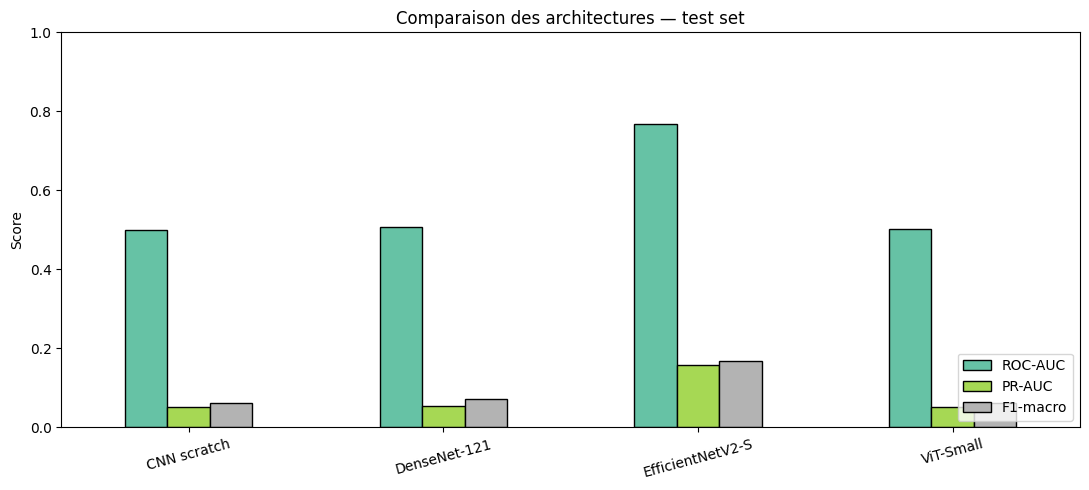


Meilleur modèle : EfficientNetV2-S → models/best_supervised_model.keras


In [14]:
results = {
    'CNN scratch':      scratch_test,
    'DenseNet-121':     dense_test,
    'EfficientNetV2-S': effnet_test,
    'ViT-Small':        vit_test,
}

cmp_df = pd.DataFrame(results).T
cmp_df.columns = ['ROC-AUC', 'PR-AUC', 'F1-macro']
cmp_df = cmp_df.round(4)
print('\n=== Comparaison test set ===')
print(cmp_df.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
cmp_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_ylabel('Score')
ax.set_title('Comparaison des architectures — test set')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(DATA_DIR / 'model_comparison.png', dpi=120)
plt.show()

# on sauvegarde le meilleur modele identifie parmi les quatre architectures
best_name   = cmp_df['ROC-AUC'].idxmax()
name_to_file = {
    'CNN scratch':      'CNN_scratch_best.keras',
    'DenseNet-121':     'DenseNet121_best.keras',
    'EfficientNetV2-S': 'EfficientNetV2S_best.keras',
    'ViT-Small':        'ViT_small_best.keras',
}
import shutil
shutil.copy(MODELS_DIR / name_to_file[best_name], MODELS_DIR / 'best_supervised_model.keras')
print(f'\nMeilleur modèle : {best_name} → models/best_supervised_model.keras')

In [15]:
# on genere un rapport detaille par classe pour le meilleur modele
best_ytrue   = {k: v for k, v in [('CNN scratch', scratch_ytrue), ('DenseNet-121', dense_ytrue),
                                    ('EfficientNetV2-S', effnet_ytrue), ('ViT-Small', vit_ytrue)]}[best_name]
best_yscores = {k: v for k, v in [('CNN scratch', scratch_yscores), ('DenseNet-121', dense_yscores),
                                    ('EfficientNetV2-S', effnet_yscores), ('ViT-Small', vit_yscores)]}[best_name]

y_pred = (best_yscores >= 0.5).astype(int)
print(f'Classification report — {best_name}:')
print(classification_report(best_ytrue, y_pred, target_names=CLASS_NAMES, zero_division=0))

Classification report — EfficientNetV2-S:
               precision    recall  f1-score   support

  atelectasis       0.19      0.78      0.31      2420
 cardiomegaly       0.08      0.77      0.14       582
     effusion       0.28      0.81      0.42      2754
 infiltration       0.28      0.54      0.37      3938
         mass       0.10      0.63      0.18      1133
       nodule       0.10      0.53      0.16      1335
    pneumonia       0.02      0.65      0.04       242
 pneumothorax       0.11      0.77      0.19      1089
consolidation       0.09      0.78      0.16       957
        edema       0.07      0.75      0.12       413
    emphysema       0.04      0.83      0.08       509
     fibrosis       0.03      0.74      0.06       362
      pleural       0.06      0.69      0.11       734
       hernia       0.01      0.86      0.01        42

    micro avg       0.11      0.69      0.19     16510
    macro avg       0.10      0.73      0.17     16510
 weighted avg       0